In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
from matplotlib import pyplot as plt


In [2]:
df = pd.read_csv('titanic.csv')

In [3]:
# entendendo a estrutura do dataset

In [4]:
df.shape

(891, 12)

In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.drop(columns=['Name'], inplace=True)

In [10]:
df = df.rename(columns={'PassengerId':'Id_passageiro', 'Survived':'Sobrevivente', 'Pclass':'Classe', 'Sex':'Sexo', 'Age':'Idade',
                   'SibSp':'Irmaos_conjunges', 'Parch':'Pais_Filhos', 'Ticket':'Bilhete', 'Fare':'Custo_Bilhete', 'Cabin':'Cabine','Embarked':'Porto_embarque'})

In [11]:
df.head()

,Id_passageiro,Sobrevivente,Classe,Sexo,Idade,Irmaos_conjunges,Pais_Filhos,Bilhete,Custo_Bilhete,Cabine,Porto_embarque
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df['Sexo'] = df['Sexo'].replace({'male':'Masculino', 'female':'Feminino'})

In [13]:
df['Custo_Bilhete'] = df['Custo_Bilhete'].round(2)

In [14]:
map_sexo = {'Masculino':0, 'Feminino':1}

In [15]:
df['Sexo (Nominal)'] = df['Sexo'].map(map_sexo)

In [16]:
map_porto = {'C':1, 'Q':2, 'S':3, 'Nao identificado':4}

In [17]:
df['Porto_embarque (Ordinal)'] = df['Porto_embarque'].map(map_porto)

In [18]:
df['Cabine'] = df['Cabine'].fillna('Nao identificado')

In [19]:
df['Idade'] = df['Idade'].fillna(np.nan)

In [20]:
df['Idade'] = df['Idade'].round(0)

In [21]:
ordenando_variaveis = ['Id_passageiro', 'Sobrevivente', 'Classe', 'Sexo', 'Sexo (Nominal)', 
                       'Idade', 'Irmaos_conjunges', 'Pais_Filhos', 'Bilhete', 'Custo_Bilhete',
                       'Cabine', 'Porto_embarque', 'Porto_embarque (Ordinal)']

df = df[ordenando_variaveis]

In [22]:
df.head()

,Id_passageiro,Sobrevivente,Classe,Sexo,Sexo (Nominal),Idade,Irmaos_conjunges,Pais_Filhos,Bilhete,Custo_Bilhete,Cabine,Porto_embarque,Porto_embarque (Ordinal)
0,1,0,3,Masculino,0,22.0,1,0,A/5 21171,7.25,Nao identificado,S,3.0
1,2,1,1,Feminino,1,38.0,1,0,PC 17599,71.28,C85,C,1.0
2,3,1,3,Feminino,1,26.0,0,0,STON/O2. 3101282,7.92,Nao identificado,S,3.0
3,4,1,1,Feminino,1,35.0,1,0,113803,53.10,C123,S,3.0
4,5,0,3,Masculino,0,35.0,0,0,373450,8.05,Nao identificado,S,3.0


In [23]:
df.describe().round(2)

,Id_passageiro,Sobrevivente,Classe,Sexo (Nominal),Idade,Irmaos_conjunges,Pais_Filhos,Custo_Bilhete,Porto_embarque (Ordinal)
count,891.00,891.00,891.00,891.00,714.00,891.00,891.00,891.00,889.00
mean,446.00,0.38,2.31,0.35,29.69,0.52,0.38,32.20,2.54
std,257.35,0.49,0.84,0.48,14.52,1.10,0.81,49.69,0.79
min,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,223.50,0.00,2.00,0.00,20.00,0.00,0.00,7.91,2.00
50%,446.00,0.00,3.00,0.00,28.00,0.00,0.00,14.45,3.00
75%,668.50,1.00,3.00,1.00,38.00,1.00,0.00,31.00,3.00
max,891.00,1.00,3.00,1.00,80.00,8.00,6.00,512.33,3.00


In [24]:
df_infantil = df.loc[df['Idade'] <= 5].copy()
df = df.drop(df.loc[df['Idade'] <= 5].index)

In [25]:
df.to_csv('titanic0_1.csv', index=False)

In [26]:
# Observando o comportamento do dataset

In [27]:
df['Idade'].min()

6.0

In [28]:
df['Idade'].max()

80.0

In [29]:
df.shape

(847, 13)

In [30]:
#criando tabela de frequência para a variável idade
classe_1 = (df.loc[(df['Idade'] >= 6) & (df['Idade'] <= 12)])
classe_2 = (df.loc[(df['Idade']>= 13) & (df['Idade'] <= 17)])
classe_3 = (df.loc[(df['Idade']>= 18) & (df['Idade'] <= 29)])
classe_4 = (df.loc[(df['Idade']>= 30) & (df['Idade'] <= 59)])
classe_5 = (df.loc[(df['Idade']>= 60) & (df['Idade'] <= 80)])
classe_6 = df.loc[df['Idade'].isnull()]

In [31]:
df['Idade'].isnull().sum()

np.int64(177)

In [32]:
df['Idade'].median()

29.0

In [33]:
df['Idade'].mean().round()

np.float64(31.0)

In [34]:
Q1 = df['Idade'].quantile(0.25)
Q2 = df['Idade'].quantile(0.50)
Q3 = df['Idade'].quantile(0.75)

In [35]:
IQR = Q3 - Q1
IA = [Q1 - (1.5*IQR), Q2 + (1.5 * IQR)]

In [36]:
IQR

np.float64(17.0)

In [37]:
IA

[np.float64(-3.5), np.float64(54.5)]

In [38]:
Cb = round(((Q3 - Q2) - (Q2- Q1))/ (IQR), 2)

In [39]:
Cb

np.float64(0.18)

In [40]:
#df['Idade'].std().round(2)

Text(0.5, 1.0, 'verificação de assimetria')

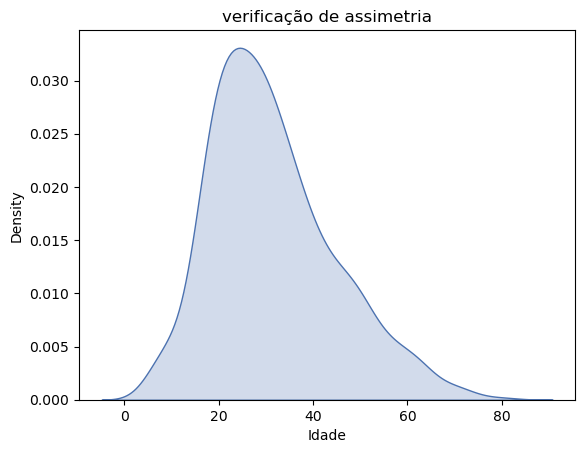

In [41]:
sns.kdeplot(df['Idade'], fill=True, color="#4C72B0")
plt.title('verificação de assimetria')

In [42]:
Q1, Q2, Q3

(np.float64(22.0), np.float64(29.0), np.float64(39.0))

In [43]:
IQR

np.float64(17.0)

In [44]:
paleta = ["#4C72B0", "#DD8452"]

<Axes: xlabel='Idade', ylabel='Sexo'>

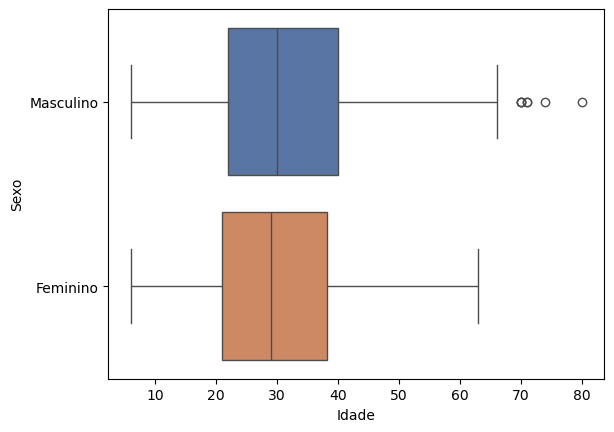

In [45]:
sns.boxplot(df, x='Idade', y='Sexo', hue='Sexo', palette=paleta)

([<matplotlib.patches.Wedge at 0x7fea15ae9010>,
 [Text(-0.5118900476346726, 0.9736367798787046, 'Masculino'),
  Text(0.5118903648857771, -0.973636613083704, 'Feminino')],
 [Text(-0.27921275325527595, 0.5310746072065661, '65.4%'),
  Text(0.27921292630133293, -0.5310745162274748, '34.6%')])

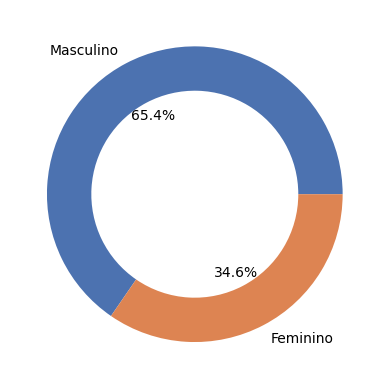

In [46]:
categorias = [len(df.loc[df['Sexo'] == 'Masculino']), len(df.loc[df['Sexo'] == 'Feminino'])]
rotulos = ['Masculino', 'Feminino']
plt.pie(categorias, labels=rotulos, colors=paleta, wedgeprops={'width':0.3},  autopct='%1.1f%%')

In [47]:
faixa = ['6-12', '13-17', '18-29', '30-59', '60-80', 'NaN']
valores = [25, 44, 271, 304, 26, 177]

Text(0.5, 0, 'Faixa Etária')

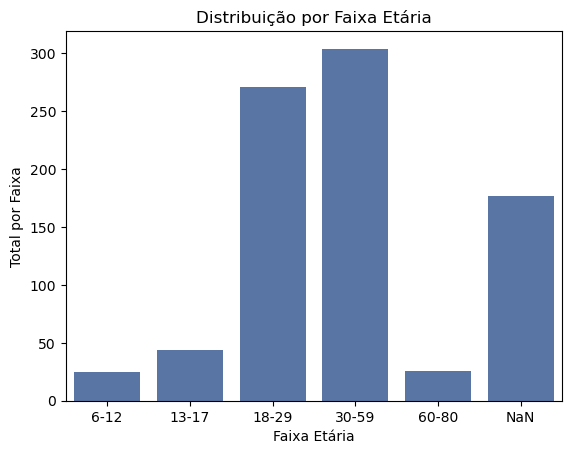

In [48]:
sns.barplot(x=faixa, y=valores, color="#4C72B0")
plt.title('Distribuição por Faixa Etária')
plt.ylabel('Total por Faixa')
plt.xlabel('Faixa Etária')

In [49]:
#retira amostral para o calculo de probabilidades condicionais
len(classe_1.loc[classe_1['Sobrevivente'] == 1])

9

In [50]:
len(classe_2.loc[classe_2['Sobrevivente'] == 1])

21

In [51]:
len(classe_3.loc[classe_3['Sobrevivente'] == 1])

95

In [52]:
len(classe_4.loc[classe_4['Sobrevivente'] == 1])

127

In [53]:
len(classe_5.loc[classe_5['Sobrevivente'] == 1])

7

In [54]:
len(classe_6.loc[classe_6['Sobrevivente'] == 1])

52

In [55]:
#calculando a probabilidade condicional de cada classe de acordo com o sexo

len(classe_1.loc[(classe_1['Sobrevivente'] == 1) & (classe_1['Sexo'] == 'Feminino')])

3

In [56]:
len(classe_2.loc[(classe_2['Sobrevivente'] == 1) & (classe_2['Sexo'] == 'Feminino')])

19

In [57]:
len(classe_3.loc[(classe_3['Sobrevivente'] == 1) & (classe_3['Sexo'] == 'Feminino')])

67

In [58]:
len(classe_4.loc[(classe_4['Sobrevivente']) & (classe_4['Sexo'] == 'Feminino')])

88

In [59]:
len(classe_5.loc[(classe_5['Sobrevivente'] == 1) & (classe_5['Sexo'] == 'Feminino')])

4

In [60]:
len(classe_6.loc[(classe_6['Sobrevivente'] == 1) & (classe_6['Sexo'] == 'Feminino')])

36

In [61]:
len(classe_1.loc[(classe_1['Sobrevivente'] == 1) & (classe_1['Sexo'] == 'Masculino')])

6

In [62]:
len(classe_2.loc[(classe_2['Sobrevivente'] == 1) & (classe_2['Sexo'] == 'Masculino')])

2

In [63]:
len(classe_3.loc[(classe_3['Sobrevivente'] == 1) & (classe_3['Sexo'] == 'Masculino')])

28

In [64]:
len(classe_4.loc[(classe_4['Sobrevivente']) & (classe_4['Sexo'] == 'Masculino')])

39

In [65]:
len(classe_5.loc[(classe_5['Sobrevivente'] == 1) & (classe_5['Sexo'] == 'Masculino')])

3

In [66]:
len(classe_6.loc[(classe_6['Sobrevivente']) & (classe_6['Sexo'] == 'Masculino')])

16

In [67]:
len(classe_2.loc[classe_2['Sexo'] == 'Feminino'])

23

In [68]:
# Visualização da taxa de sobrevivência de sexo por faixa etária

data = {
    'Faixa Etária': ['6-12', '13-17', '18-29', '30-59', '60-80', 'NaN'] * 2,
    'Percentual de Sobrevivência': [27, 83, 73, 80, 100, 68,  
                                  73, 10, 16, 20, 14, 13], 
    'Sexo': ['Feminino'] * 6 + ['Masculino'] * 6
}


Text(0.5, 1.0, 'Probabilidade de Sobrevivência por Faixa Etária')

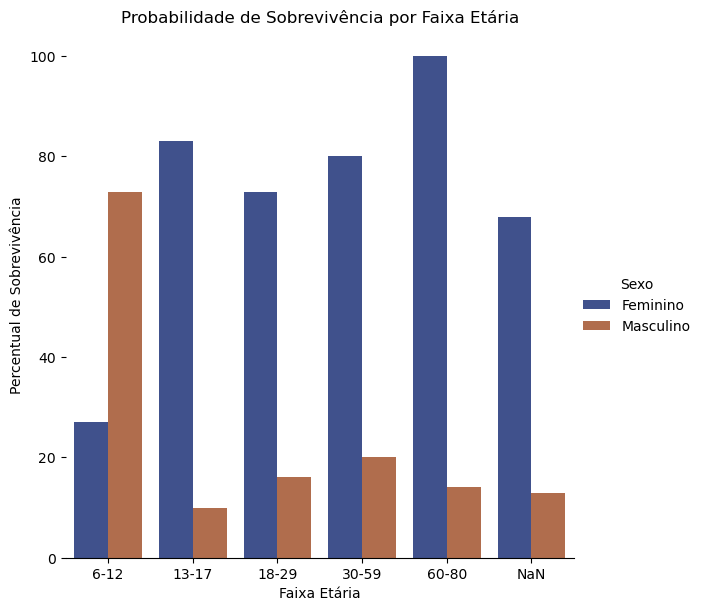

In [69]:
chart = sns.catplot(data=data, kind='bar', x='Faixa Etária', y='Percentual de Sobrevivência', hue='Sexo', palette='dark',
                   errorbar='sd', alpha=.8, height=6)
chart.despine(left=True)
plt.title('Probabilidade de Sobrevivência por Faixa Etária')

In [70]:
df.dtypes

Id_passageiro                 int64
Sobrevivente                  int64
Classe                        int64
Sexo                         object
Sexo (Nominal)                int64
Idade                       float64
Irmaos_conjunges              int64
Pais_Filhos                   int64
Bilhete                      object
Custo_Bilhete               float64
Cabine                       object
Porto_embarque               object
Porto_embarque (Ordinal)    float64
dtype: object

In [71]:
df.groupby('Classe').agg({'Classe':'count','Custo_Bilhete':'median', 'Idade':'median'})

,Classe,Custo_Bilhete,Idade
Classe,,,
1,213,57.98,38.0
2,171,13.50,30.0
3,463,8.05,25.0


In [72]:
len(df.loc[df['Porto_embarque'] == 'C'])

160

In [73]:
len(df.loc[df['Porto_embarque'] == 'Q'])

75

In [74]:
len(df.loc[df['Porto_embarque'] == 'S'])

610

Text(0.5, 1.0, 'Distribuição por Porto de Embarque')

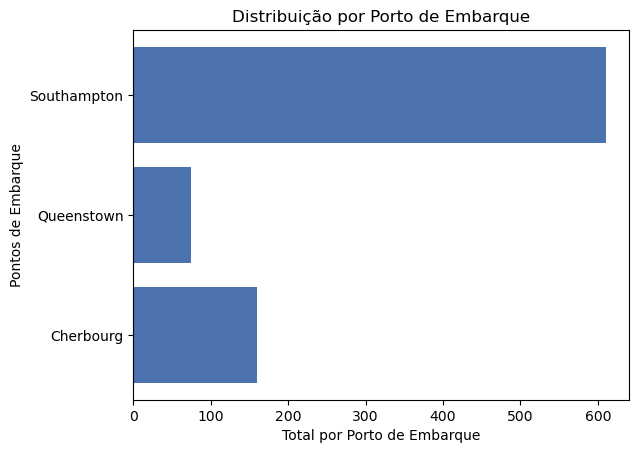

In [75]:
valores = [160, 75, 610]
rotulos = ['Cherbourg', 'Queenstown', 'Southampton']

plt.barh(rotulos, valores, color='#4C72B0')
plt.ylabel('Pontos de Embarque')
plt.xlabel('Total por Porto de Embarque')
plt.title('Distribuição por Porto de Embarque')

In [76]:
classes = [213, 171, 463]
rotulos = ['1° Classe', '2° Classe', '3° Classe']

Text(0.5, 1.0, 'Distribuição por classes geral')

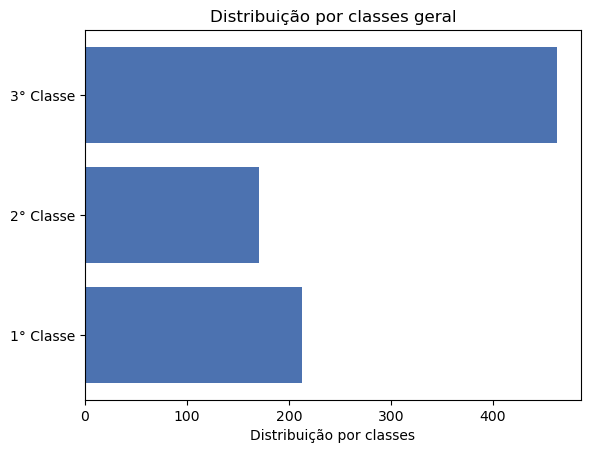

In [77]:
plt.barh(rotulos, classes, color='#4C72B0')
plt.xlabel('Distribuição por classes')
plt.title('Distribuição por classes geral')

In [78]:
df.head()

,Id_passageiro,Sobrevivente,Classe,Sexo,Sexo (Nominal),Idade,Irmaos_conjunges,Pais_Filhos,Bilhete,Custo_Bilhete,Cabine,Porto_embarque,Porto_embarque (Ordinal)
0,1,0,3,Masculino,0,22.0,1,0,A/5 21171,7.25,Nao identificado,S,3.0
1,2,1,1,Feminino,1,38.0,1,0,PC 17599,71.28,C85,C,1.0
2,3,1,3,Feminino,1,26.0,0,0,STON/O2. 3101282,7.92,Nao identificado,S,3.0
3,4,1,1,Feminino,1,35.0,1,0,113803,53.10,C123,S,3.0
4,5,0,3,Masculino,0,35.0,0,0,373450,8.05,Nao identificado,S,3.0


In [79]:
df.groupby(['Classe', 'Sexo (Nominal)'])['Sobrevivente'].mean().round(2) * 100

Classe  Sexo (Nominal)
1       0                 36.0
        1                 98.0
2       0                  9.0
        1                 92.0
3       0                 13.0
        1                 47.0
Name: Sobrevivente, dtype: float64

In [80]:
# A politica de mulheres e crianças primeiro teve algum vies?

hipotese = {
    'classes': ['1° classe', '2° classe', '3° classe', '1° classe', '2° classe', '3° classe'],
    'Percentual de Sobrevivência por classe': [98, 92, 47,
                                               36, 9, 13], 
    'Sexo': ['Feminino'] * 3 + ['Masculino'] * 3
}


Text(0.5, 1.0, 'Percentual de sobrevivência por classe e sexo')

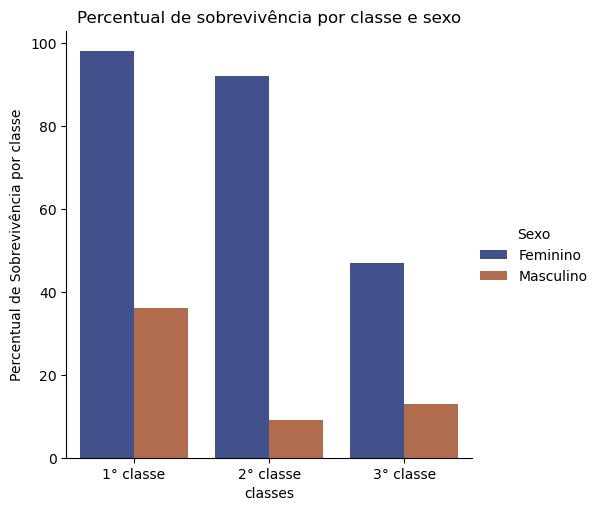

In [81]:
sns.catplot(data=hipotese, x='classes', y='Percentual de Sobrevivência por classe', kind='bar', hue='Sexo', palette='dark', alpha=.8)
plt.title('Percentual de sobrevivência por classe e sexo')

<Axes: xlabel='Idade', ylabel='Sobrevivente'>

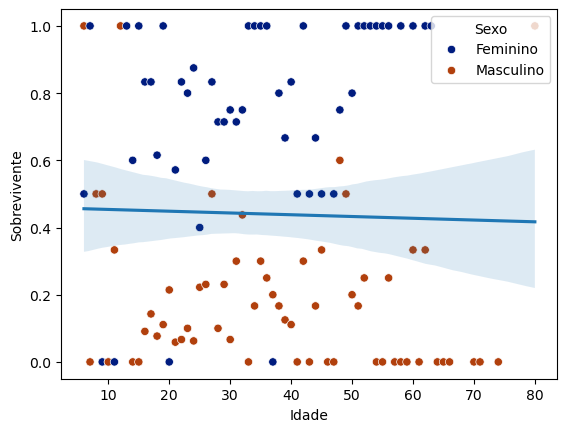

In [82]:
# gerando scarplot 

agrupamento = df.groupby(['Idade', 'Sexo'])['Sobrevivente'].mean().reset_index()


sns.scatterplot(data=agrupamento, x='Idade', y='Sobrevivente', hue='Sexo', palette='dark')
sns.regplot(data=agrupamento, x='Idade', y='Sobrevivente', scatter=False)

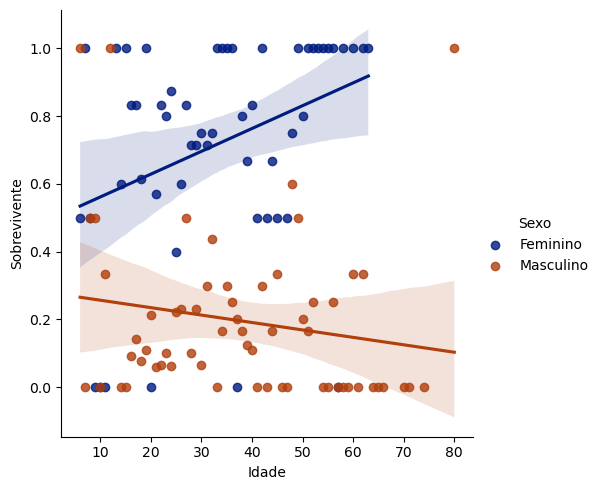

In [83]:
sns.lmplot(data=agrupamento, x='Idade', y='Sobrevivente', hue='Sexo', palette='dark')

In [84]:
#verificando a probabilidade de sobrevivência para o segundo conjunto de dados

In [85]:
df_infantil.head()

,Id_passageiro,Sobrevivente,Classe,Sexo,Sexo (Nominal),Idade,Irmaos_conjunges,Pais_Filhos,Bilhete,Custo_Bilhete,Cabine,Porto_embarque,Porto_embarque (Ordinal)
7,8,0,3,Masculino,0,2.0,3,1,349909,21.08,Nao identificado,S,3.0
10,11,1,3,Feminino,1,4.0,1,1,PP 9549,16.70,G6,S,3.0
16,17,0,3,Masculino,0,2.0,4,1,382652,29.12,Nao identificado,Q,2.0
43,44,1,2,Feminino,1,3.0,1,2,SC/Paris 2123,41.58,Nao identificado,C,1.0
58,59,1,2,Feminino,1,5.0,1,2,C.A. 34651,27.75,Nao identificado,S,3.0


In [86]:
media_infantil = df_infantil['Idade'].mean().round(2)
media_infantil

np.float64(2.52)

In [88]:
#mediana = df_infantil['Idade'].median().round(2)
#mediana

In [89]:
Q1_infantil = df_infantil['Idade'].quantile(0.25)
Q2_infantil = df_infantil['Idade'].quantile(0.50)
Q3_infantil = df_infantil['Idade'].quantile(0.75)

In [90]:
Q1_infantil, Q2_infantil, Q3_infantil

(np.float64(1.0), np.float64(2.0), np.float64(4.0))

In [91]:
IQR_infantil = Q3_infantil - Q1_infantil
IQR_infantil

np.float64(3.0)

In [92]:
IA_infantil = [Q1_infantil- (1.5 * IQR_infantil), Q3_infantil + (1.5 * IQR_infantil)]

In [93]:
IA_infantil

[np.float64(-3.5), np.float64(8.5)]

In [104]:
CB = (((Q3_infantil - Q2_infantil) - (Q2_infantil - Q1_infantil)) / (IQR_infantil))
round(CB, 2)

np.float64(0.33)

In [100]:
#desvio_infantil = df_infantil['Idade'].std().round(2)
#desvio_infantil

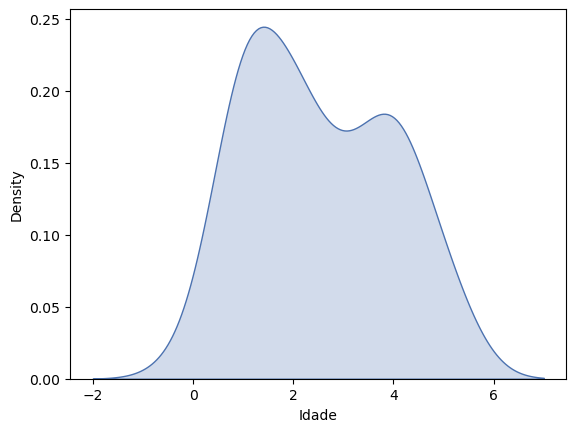

In [106]:
sns.kdeplot(df_infantil['Idade'], fill=True, color="#4C72B0")
plt.savefig('kde_infantil_plot.png', dpi=300, bbox_inches='tight')

In [95]:
distribuicao_infantil = [len(df_infantil.loc[df_infantil['Sexo'] == 'Masculino']), len(df_infantil.loc[df_infantil['Sexo'] == 'Feminino'])]
distribuicao_rotulos_infantil = ['Masculino', 'Feminino']

Text(0.5, 1.0, 'Distribuição_infantil')

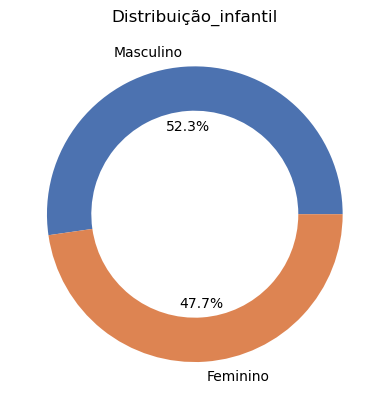

In [96]:
plt.pie(distribuicao_infantil, labels=distribuicao_rotulos_infantil,
        wedgeprops={'width':0.3},  autopct='%1.1f%%', colors=paleta)
plt.title('Distribuição_infantil')

In [97]:
agrupamento_infantil = df_infantil.groupby(['Idade', 'Sexo'])['Sobrevivente'].mean().reset_index()

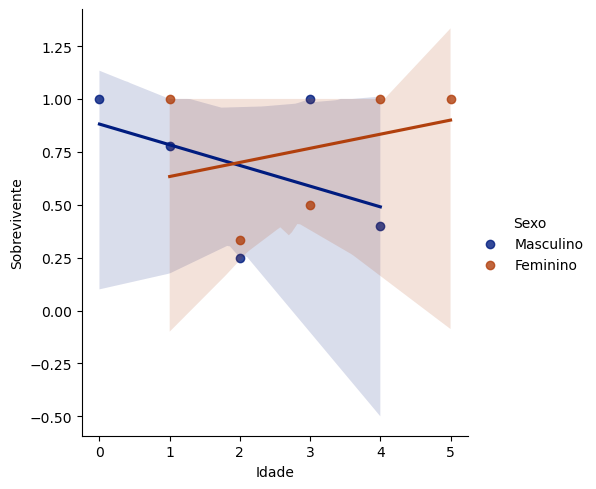

In [134]:
sns.lmplot(data=agrupamento_infantil, x='Idade', y='Sobrevivente', hue='Sexo', palette='dark')
plt.savefig('escala_sobrevivencia.png', dpi=300, bbox_inches='tight')

In [119]:
F = len(df_infantil.loc[(df_infantil['Sobrevivente'] == 1) & (df_infantil['Sexo'] == 'Feminino')])
F

16

In [118]:
M = len(df_infantil.loc[(df_infantil['Sobrevivente'] == 1) & (df_infantil['Sexo'] == 'Masculino')])
M

15

In [125]:
len(df_infantil.loc[df_infantil['Sexo'] == 'Feminino'])

21

In [126]:
len(df_infantil.loc[df_infantil['Sexo'] == 'Masculino'])

23

In [127]:
Tx_Sv_infantil = [76, 65]
rotulos = ['Feminino', 'Masculino']

/tmp/ipykernel_58733/2320621285.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rotulos, y=Tx_Sv_infantil, palette='dark')


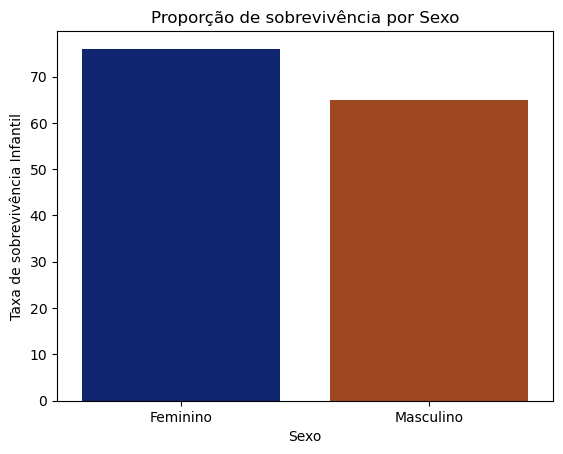

In [133]:
sns.barplot(x=rotulos, y=Tx_Sv_infantil, palette='dark')
plt.xlabel('Sexo')
plt.ylabel('Taxa de sobrevivência Infantil')
plt.title('Proporção de sobrevivência por Sexo')
plt.savefig('Sobrevivencia_infantil.png', dpi=300, bbox_inches='tight')